In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from xgboost import XGBClassifier

import optuna

C:\Users\Madhu\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
rfm = pd.read_csv(
    "../data/processed/rfm_customer_data.csv"
)

rfm["Churn"] = np.where(
    rfm["Recency"] > 90,
    1,
    0
)

rfm.head()

,Customer ID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Churn
0,12346.0,326,12,77556.46,2,5,5,255,1
1,12347.0,2,8,5633.32,5,4,5,545,0
2,12348.0,75,5,2019.40,3,4,4,344,0
3,12349.0,19,4,4428.69,5,3,5,535,0
4,12350.0,310,1,334.40,2,1,2,212,1


In [4]:
X = rfm.drop(
    columns=["Customer ID", "Churn"]
)

y = rfm["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators",
            50,
            300
        ),

        "max_depth": trial.suggest_int(
            "max_depth",
            3,
            10
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.3
        ),

        "subsample": trial.suggest_float(
            "subsample",
            0.5,
            1.0
        ),

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree",
            0.5,
            1.0
        )
    }

    model = XGBClassifier(
        **params,
        random_state=42
    )

    model.fit(
        X_train,
        y_train
    )

    preds = model.predict(X_test)

    accuracy = accuracy_score(
        y_test,
        preds
    )

    return accuracy

In [6]:
study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=20
)

print("Best Accuracy:")
print(study.best_value)

print("\nBest Parameters:")
print(study.best_params)

[I 2026-06-14 22:16:23,409] A new study created in memory with name: no-name-4173a2ba-db9d-439f-8151-c5ada9790638
[I 2026-06-14 22:16:23,599] Trial 0 finished with value: 1.0 and parameters: {'n_estimators': 215, 'max_depth': 9, 'learning_rate': 0.07331609128678974, 'subsample': 0.830918536798618, 'colsample_bytree': 0.5658755025732416}. Best is trial 0 with value: 1.0.
[I 2026-06-14 22:16:23,681] Trial 1 finished with value: 1.0 and parameters: {'n_estimators': 176, 'max_depth': 5, 'learning_rate': 0.13452205964542868, 'subsample': 0.6364534289580566, 'colsample_bytree': 0.9161414488913809}. Best is trial 0 with value: 1.0.
[I 2026-06-14 22:16:23,793] Trial 2 finished with value: 1.0 and parameters: {'n_estimators': 280, 'max_depth': 5, 'learning_rate': 0.20334007789145336, 'subsample': 0.5906001306191226, 'colsample_bytree': 0.8515633785557395}. Best is trial 0 with value: 1.0.
[I 2026-06-14 22:16:23,908] Trial 3 finished with value: 1.0 and parameters: {'n_estimators': 239, 'max_dep

Best Accuracy:
1.0

Best Parameters:
{'n_estimators': 215, 'max_depth': 9, 'learning_rate': 0.07331609128678974, 'subsample': 0.830918536798618, 'colsample_bytree': 0.5658755025732416}


In [7]:
best_model = XGBClassifier(
    **study.best_params,
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

preds = best_model.predict(
    X_test
)

accuracy = accuracy_score(
    y_test,
    preds
)

print("Final Accuracy:", accuracy)

Final Accuracy: 1.0


In [8]:
best_params_df = pd.DataFrame(
    [study.best_params]
)

best_params_df.to_csv(
    "../data/processed/best_xgb_params.csv",
    index=False
)

print("Best parameters saved!")

Best parameters saved!


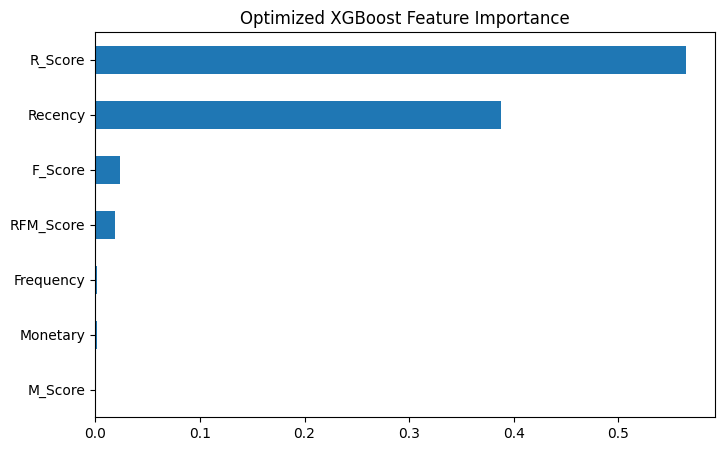

In [9]:
import matplotlib.pyplot as plt

importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title(
    "Optimized XGBoost Feature Importance"
)

plt.savefig(
    "../screenshots/optuna_feature_importance.png"
)

plt.show()